# 4.1

### 경사하강법 구현하기(p.153-154)

1.2532418085611319 2.745502230882486


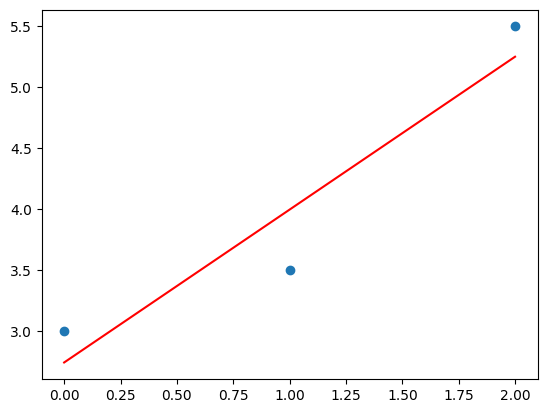

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([0.0, 1.0, 2.0])
y = np.array([3.0, 3.5, 5.5])

w = 0   # 기울기
b = 0   # 절편

lrate = 0.01    # 학습률
epochs = 1000   # 반복 횟수

n = float(len(X))   # 입력 데이터의 개수

# 경사 하강법
for i in range(epochs):
    y_pred = w*X + b            # 선형 회귀 예측값
    dw = (2/n) * sum(X * (y_pred-y))    # 넘파이 배열간의 산술 계산은 요소별로 적용
    db = (2/n) * sum(y_pred-y)          # sum()은 모든 요소들의 합을 계산하는 내장 함수
    w = w - lrate * dw                  # 기울기 수정
    b = b - lrate * db                  # 절편 수정

# 기울기와 절편을 출력한다.
print(w, b)

# 예측값을 만든다.
y_pred = w*X + b

# 입력 데이터를 그래프 상에 찍는다.
plt.scatter(X, y)

# 예측값은 선그래프로 그린다.
plt.plot([min(X), max(X)], [min(y_pred), max(y_pred)], color='red')
plt.show()

### 선형 회귀 구현 #2(p.154-156)

In [ ]:
import matplotlib.pyplot as plt
from sklearn import linear_model

# 선형 회귀 모델을 생성한다.
reg = linear_model.LinearRegression()

# 데이터는 파이썬의 리스트로 만들어도 되고 아니면 넘파이의 배열로 만들어도 됨
X = [[0], [1], [2]]     # 반드시 2차원으로 만들어야 함
y = [3, 3.5, 5.5]       # y = x + 3

# 학습을 시킨다.
reg.fit(X, y)

LinearRegression()

In [ ]:
reg.coef_   # 직선의 기울기

array([1.25])

In [ ]:
reg.intercept_  # 직선의 y-절편

np.float64(2.7500000000000004)

In [ ]:
reg.score(X, y)

0.8928571428571429

In [ ]:
reg.predict([[5]])

array([9.])

In [ ]:
# 학습 데이터와 y 값을 산포도로 그린다.
plt.scatter(X, y, color='black')

# 학습 데이터를 입력으로 하여 예측값을 계산한다.
y_pred = reg.predict(X)

# 학습 데이터와 예측값으로 선그래프로 그린다.
# 계산된 기울기와 y 절편을 가지는 직선이 그려진다.
plt.plot(X, y_pred, color='blue', linewidth=3)
plt.show()

### 선형 회귀 실습(p.157)

[67.30998637]


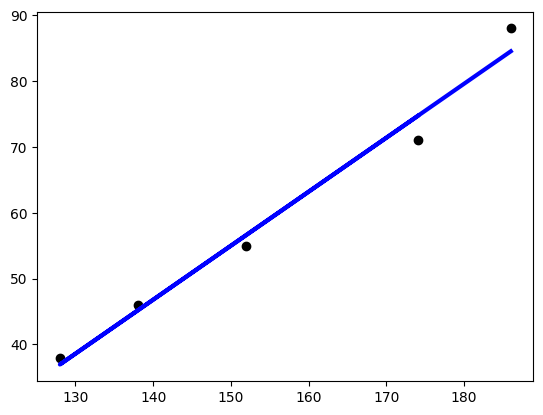

In [ ]:
import matplotlib.pyplot as plt
from sklearn import linear_model

reg = linear_model.LinearRegression()

X = [[174], [152], [138], [128], [186]]
y = [71, 55, 46, 38, 88]

reg.fit(X, y)       # 학습

print(reg.predict([[165]]))

# 학습 데이터와 y 값을 산포도로 그린다.
plt.scatter(X, y, color='black')

# 학습 데이터를 입력으로 하여 예측값을 계산한다.
y_pred = reg.predict(X)

# 학습 데이터와 예측값으로 선그래프로 그린다.
# 계산된 기울기와 y 절편을 가지는 직선이 그려진다.
plt.plot(X, y_pred, color='blue', linewidth=3)
plt.show()

### 당뇨병 예제(p.160-161)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import datasets

# 당뇨병 데이터 세트를 적재한다.
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

In [ ]:
diabetes_X.data.shape

(442, 10)

In [ ]:
# 하나의 특징(BMI)만 추려내서 2차원 배열로 만든다. BMI 특징의 인덱스가 2이다.
diabetes_X_new = diabetes_X[:, np.newaxis, 2]

In [ ]:
# 훈련 데이터와 테스트 데이터를 분리한다.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(diabetes_X_new, diabetes_y, test_size=0.1, random_state=0)

# 선형 회귀 모델로 학습을 수행한다.
regr = LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 기울기와 절편을 출력한다.
print(f"기울기(coef): {regr.coef_[0]:.2f}")
print(f"절편(intercept): {regr.intercept_:.2f}")
print(f"R² 스코어: {regr.score(X_test, y_test):.4f}")

기울기(coef): 966.73
절편(intercept): 151.21
R² 스코어: 0.1914


In [ ]:
# 테스트 데이터로 예측해보자.
y_pred = regr.predict(X_test)

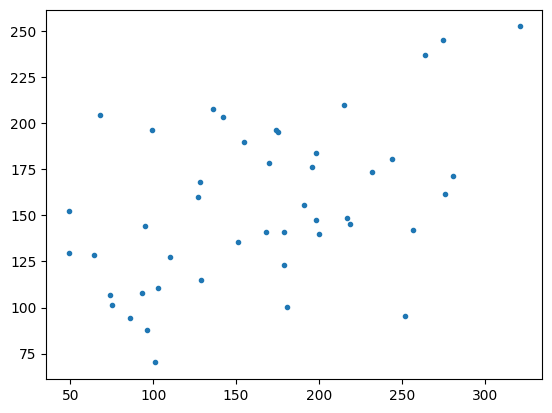

In [ ]:
# 실제 데이터와 예측 데이터를 비교해보자
plt.plot(y_test, y_pred, '.')

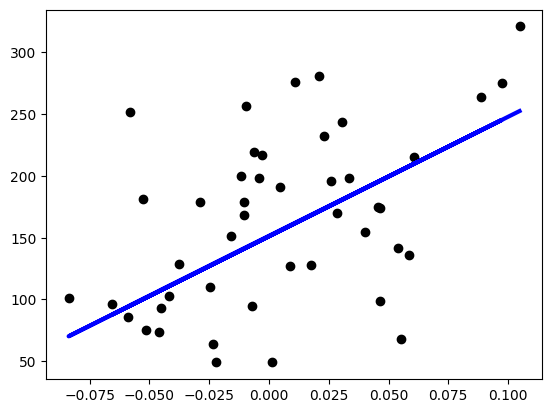

In [ ]:
plt.scatter(X_test, y_test, color='black')
plt.plot(X_test, y_pred, color='blue', linewidth=3)
plt.show()

### 면적에 따른 집값 예측(p.162)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

In [ ]:
# 학습 데이터 (면적: 평, 가격: 억원)

X = [[20], [25], [30], [40], [50], [60], [70], [80], [90], [100],[110], [120], [130], [140], [150], [155], [160], [165], [170], [175]]

y = [4, 5, 6.5, 8, 10, 13, 13.5, 15, 16.5, 19.5,20, 23, 25, 28, 30, 30, 31, 30.5, 33, 33.5]

In [ ]:
reg.fit(X, y)   # 학습

LinearRegression()

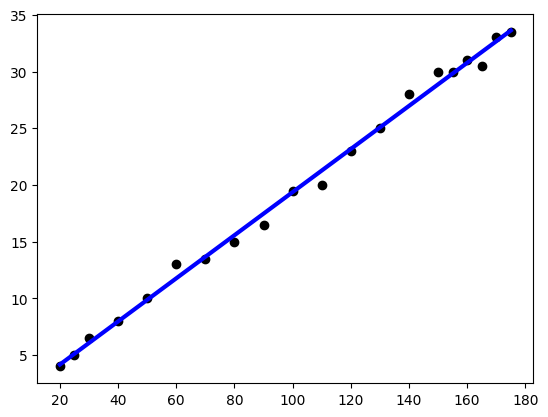

In [ ]:
# 학습 데이터와 y 값을 산포도로 그린다.
plt.scatter(X, y, color='black')

# 학습 데이터를 입력으로 하여 예측값을 계산한다.
y_pred = reg.predict(X)

# 학습 데이터와 예측값으로 선그래프로 그린다.
# 계산된 기울기와 y 절편을 가지는 직선이 그려진다.
plt.plot(X, y_pred, color='blue', linewidth=3)
plt.show()

In [ ]:
apart_size = int(input("아파트 면적을 입력하세요."))

X_new = [[apart_size]]
predict = reg.predict(X_new) # 아파트 면적에 따른 예상 집값 계산

print("예상 집값은" + str(predict[0]) + "억 원입니다.")

아파트 면적을 입력하세요.88
예상 집값은17.0902120408936억 원입니다.


# 4.1 연습문제

### 연습문제 1

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

reg = LinearRegression()    # 선형 회귀 모델 생성

In [ ]:
# 학습 데이터 (공부 시간, 시험 점수)

X = [[1], [2], [3], [4], [5], [6]]
y = [20, 33, 50, 65, 72, 85]

In [ ]:
reg.fit(X, y)      # 학습

LinearRegression()

In [ ]:
# 모델 정보 출력
print("=" * 40)
print("   시험 점수 예측 모델")
print("=" * 40)
print(f"기울기(coef): {reg.coef_[0]:.4f}")
print(f"절편(intercept): {reg.intercept_:.4f}")
print(f"R² 스코어: {reg.score(X, y):.4f}")
print(f"모델 수식: 점수 = {reg.coef_[0]:.4f} × 공부 시간 + {reg.intercept_:.4f}")
print("=" * 40)

   시험 점수 예측 모델
기울기(coef): 13.0571
절편(intercept): 8.4667
R² 스코어: 0.9883
모델 수식: 점수 = 13.0571 × 공부 시간 + 8.4667


In [ ]:
time = 3.5
score = reg.predict([[time]])

print(f"하루에 {time}시간 공부했을 때, 예상 점수는 {score[0]:.2f}점입니다.")

하루에 3.5시간 공부했을 때, 예상 점수는 54.17점입니다.


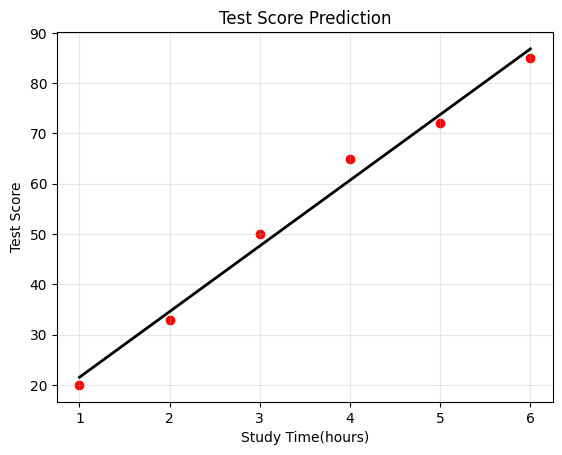

In [ ]:
# 학습 데이터와 예측 직선 그래프
plt.scatter(X, y, color='red')
y_pred = reg.predict(X)
plt.plot(X, y_pred, color='black', linewidth=2)
plt.xlabel('Study Time(hours)')
plt.ylabel('Test Score')
plt.title('Test Score Prediction')
plt.grid(True, alpha=0.3)
plt.savefig('testScore_plot.png', dpi=150)
plt.show()

### 연습문제 2



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])

In [ ]:
def gradient_descent(X, y, lrate, epochs):
    w = 0   # 기울기
    b = 0   # 절편

    n = float(len(X))   # 입력 데이터의 개수

    # 경사 하강법 구현
    for i in range(epochs):
        y_pred = w*X + b    # 선형 회귀 예측값
        dw = (2/n) * sum(X * (y_pred-y))    # 넘파이 배열간의 산술 계산은 요소별로 적용
        db = (2/n) * sum(y_pred-y)          # sum()은 모든 요소들의 합을 계산하는 내장 함수
        w = w - lrate * dw                  # 기울기 수정
        b = b - lrate * db                  # 절편 수정

    return w, b

(1) W=0, b=0에서 시작하여 학습률 0.01로 1000번 반복한 후 W와 b를 출력한 기존 결과가 y = 2x + 1에 가까운지 확인하세요.

In [ ]:
w, b = gradient_descent(X, y, 0.01, 1000)

print(f"w = {w:.2f}, b = {b:.2f}")

w = 2.00, b = 0.99


(3) 반복 횟수를 10, 100, 1000으로 바꿔가며 W와 b가 어떻게 변하는지 비교하고, 그 이유를 설명하세요.

In [ ]:
# 반복 횟수 10
w, b = gradient_descent(X, y, 0.01, 10)

print(f"w = {w:.2f}, b = {b:.2f}")

w = 1.97, b = 0.56


In [ ]:
# 반복 횟수 100
w, b = gradient_descent(X, y, 0.01, 100)

print(f"w = {w:.2f}, b = {b:.2f}")

w = 2.08, b = 0.70


In [ ]:
# 반복 횟수 1000
w, b = gradient_descent(X, y, 0.01, 1000)

print(f"w = {w:.2f}, b = {b:.2f}")

w = 2.00, b = 0.99


반복 횟수를 바꾸면 W, b가 변하는 이유:
반복 횟수가 증가할수록 W, b가 y = 2x + 1에 가까워지는 것으로 보인다. 경사하강법은 반복적으로 손실 함수의 기울기를 계산하며 매개 변수를 수정하는 것이기 때문에, 더 많이 반복할수록 점점 실제 값에 가까워진다.

### 연습문제 3

In [ ]:
# 160-161p에서 구현한 당뇨병 예제

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import datasets

diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)

In [ ]:
diabetes_X.data.shape

(442, 10)

In [ ]:
diabetes_X_new = diabetes_X[:, np.newaxis, 2]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(diabetes_X_new, diabetes_y, test_size=0.1, random_state=0)

regr = LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

(1) BMI 하나만 사용한 단순 선형 회귀에서 기울기(coef)와 절편(intercept) 확인

In [ ]:
print(f"기울기(coef): {regr.coef_[0]:.2f}")
print(f"절편(intercept): {regr.intercept_:.2f}")
print(f"R² 스코어: {regr.score(X_test, y_test):.4f}")

기울기(coef): 966.73
절편(intercept): 151.21
R² 스코어: 0.1914


(2) 10개 특징 전부를 사용한 다중 선형 회귀 모델

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(diabetes_X, diabetes_y, test_size=0.1, random_state=0)

regr = LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(f"기울기(coef): {regr.coef_[0]:.2f}")
print(f"절편(intercept): {regr.intercept_:.2f}")
print(f"R² 스코어: {regr.score(X_test, y_test):.4f}")

기울기(coef): -38.78
절편(intercept): 151.72
R² 스코어: 0.3572


(3) BMI만 사용한 모델과 10개 전부 사용한 모델의 score() 결과를 비교하고, 왜 차이가 나는지 설명하세요.

BMI만 사용한 모델은 score() 결과가 약 0.19이고 10개 전부 사용한 모델은 약 0.35로, 모든 특징을 사용한 모델이 하나의 특징만 사용한 모델보다 R²스코어가 높게 나타난다. R²스코어는 1에 가까울 수록 모델이 데이터를 잘 설명하는 것이다. 10개의 특징을 모두 사용한 다중 선형 회귀의 경우에는 더 많은 정보를 반영하기 때문에 일반적으로 1개의 특징만 사용한 단순 선형 회귀보다 모델이 데이터를 잘 설명한다고 볼 수 있다.